# US dollars to Indian Rupees Exchange Rate Forecasting using ARIMA

Importing dependancies & dataset

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

Total Trading Days Recorded: 1624
Chronological Range: 2020-01-01 to 2026-03-30

First 5 Rows (Start of Data)
Price           Close
Date                 
2020-01-01  71.275803
2020-01-02  71.025002
2020-01-03  71.415001
2020-01-06  71.731003
2020-01-07  71.787003

 Last 5 Rows (Current 2026 Data)
Price           Close
Date                 
2026-03-24  93.243698
2026-03-25  94.299698
2026-03-26  94.693703
2026-03-27  94.309502
2026-03-30  94.386002


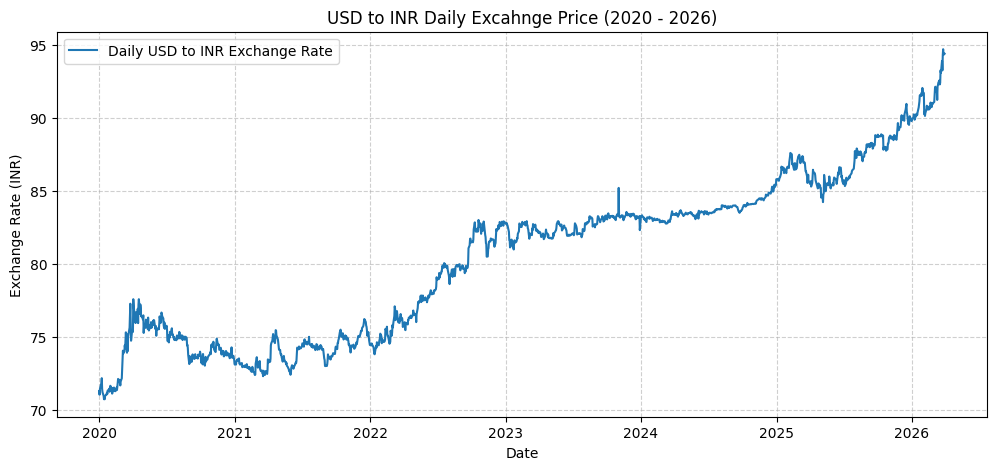

In [ ]:
#Downloading data from yfinance API
df = yf.download("INR=X", start="2020-01-01", progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

#Isolate the 'Close' price and drop any market holidays (NaN values)
df = df[['Close']].dropna()

print(f"Total Trading Days Recorded: {df.shape[0]}")
print(f"Chronological Range: {df.index.min().date()} to {df.index.max().date()}\n")
print("First 5 Rows (Start of Data)")
print(df.head())
print("\n Last 5 Rows (Current 2026 Data)")
print(df.tail())

#Visualize Original Time Series Data
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], color='#1f77b4', linewidth=1.5, label='Daily USD to INR Exchange Rate')
plt.title('USD to INR Daily Excahnge Price (2020 - 2026)')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Statistical Techniques and Data Preparations

Moving Average Analysis

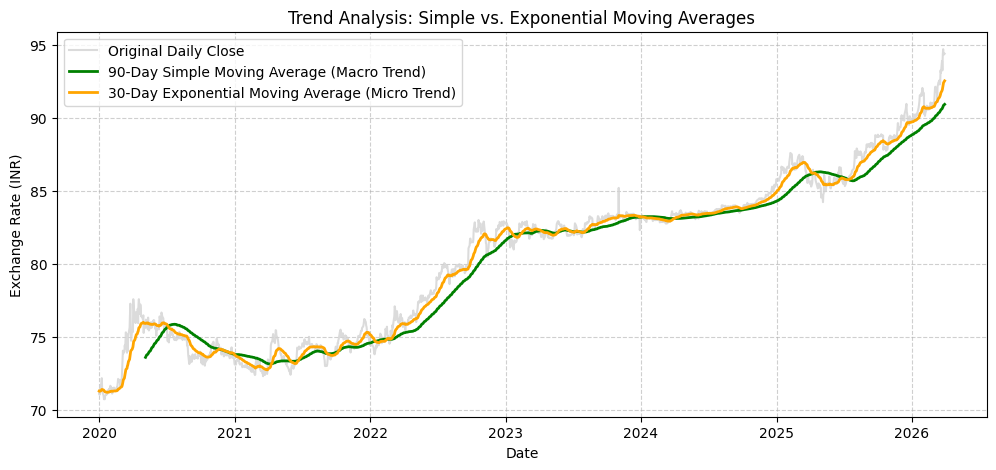

In [3]:
# Moving Average Analysis (SMA vs EMA)
df['SMA_90'] = df['Close'].rolling(window=90).mean()
df['EMA_30'] = df['Close'].ewm(span=30, adjust=False).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label='Original Daily Close', color='lightgray', alpha=0.8)
plt.plot(df.index, df['SMA_90'], label='90-Day Simple Moving Average (Macro Trend)', color='green', linewidth=2)
plt.plot(df.index, df['EMA_30'], label='30-Day Exponential Moving Average (Micro Trend)', color='orange', linewidth=2)

plt.title('Trend Analysis: Simple vs. Exponential Moving Averages')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Correlation Analysis (Lag Dependancy)

Correlation (Lag Analysis)
Lag 1 Correlation: 0.9988


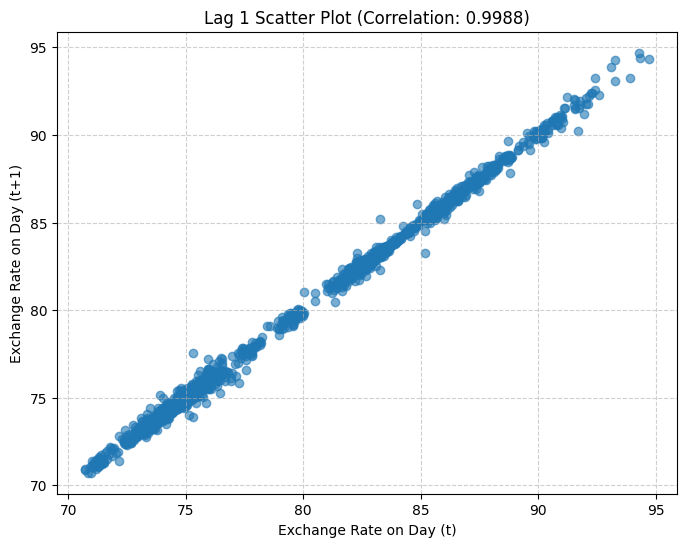

In [9]:
lag_1_corr = df['Close'].autocorr(lag=1) #Calculating the exact mathematical correlation for Lag 1 (Yesterday vs Today)

print("Correlation (Lag Analysis)")
print(f"Lag 1 Correlation: {lag_1_corr:.4f}")

plt.figure(figsize=(8, 6))
lag_plot(df['Close'], c='#1f77b4', alpha=0.6)
plt.title(f'Lag 1 Scatter Plot (Correlation: {lag_1_corr:.4f})')
plt.xlabel('Exchange Rate on Day (t)')
plt.ylabel('Exchange Rate on Day (t+1)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

ADF Test

Augmented Dickey-Fuller Test (ADF)(Original Data)
ADF Statistic: 0.2293
p-value: 0.9739


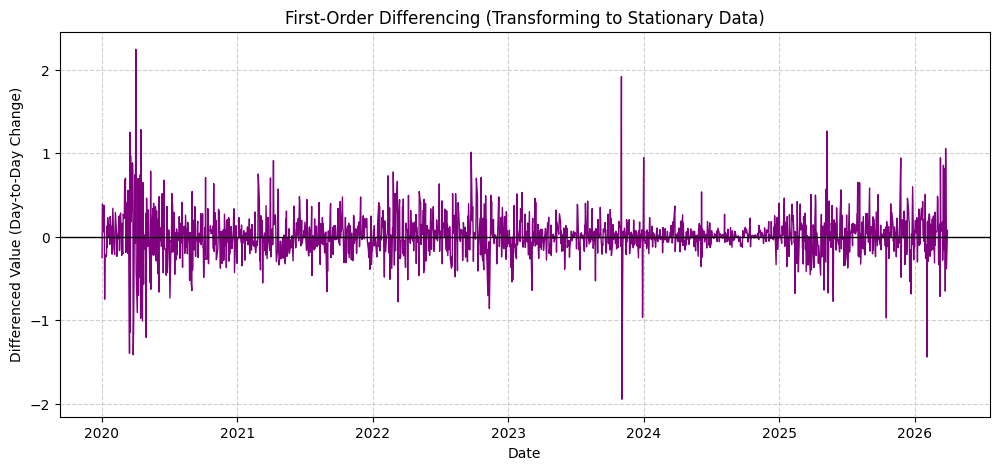


Augmented Dickey-Fuller Test (ADF)(Differenced Data)
ADF Statistic: -48.5080
p-value: 0.0000


In [5]:
# Stationarity Test
print("Augmented Dickey-Fuller Test (ADF)(Original Data)")
adf_result = adfuller(df['Close'])
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')

# Applying First-Order Differencing
df['Differenced'] = df['Close'].diff().dropna()

# Plotting the Differenced Data
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Differenced'], color='purple', linewidth=1)
plt.title('First-Order Differencing (Transforming to Stationary Data)')
plt.xlabel('Date')
plt.ylabel('Differenced Value (Day-to-Day Change)')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nAugmented Dickey-Fuller Test (ADF)(Differenced Data)")
adf_diff = adfuller(df['Differenced'].dropna())
print(f'ADF Statistic: {adf_diff[0]:.4f}')
print(f'p-value: {adf_diff[1]:.4f}')

#### ARIMA Forecasting

Training final model on complete dataset...


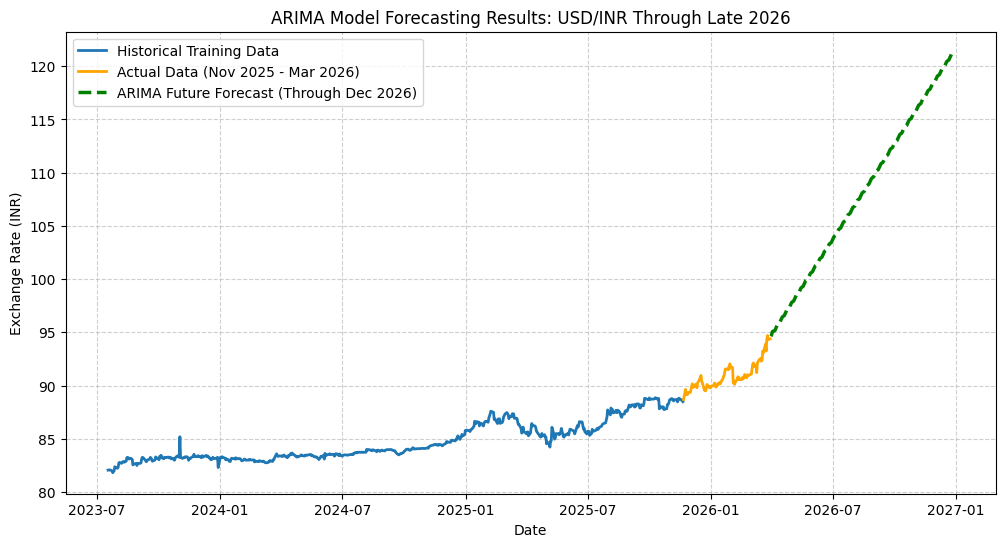

In [6]:
#Train-Test Split (Last 90 days for testing)
train_data = df['Close'][:-90]
test_data = df['Close'][-90:]

#Building Model (testing)
model_train = ARIMA(train_data, order=(5, 2, 0))
fitted_train = model_train.fit()

# Get predictions for the 90-day test period to evaluate accuracy later
test_predictions = fitted_train.forecast(steps=len(test_data))

print("Training final model on complete dataset...") #(training)
model_full = ARIMA(df['Close'], order=(5, 2, 0))
fitted_full = model_full.fit()

future_steps = 195 # Forecasting roughly 195 business days (late December 2026)
future_forecast = fitted_full.forecast(steps=future_steps)
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='B')

#Visualising the Forecast
plt.figure(figsize=(12, 6))
plt.plot(df.index[-700:-90], train_data[-610:], label='Historical Training Data', color='#1f77b4', linewidth=2)
plt.plot(test_data.index, test_data, label='Actual Data (Nov 2025 - Mar 2026)', color='orange', linewidth=2)
plt.plot(future_dates, future_forecast, label='ARIMA Future Forecast (Through Dec 2026)', color='green', linestyle='dashed', linewidth=2.5)
plt.title('ARIMA Model Forecasting Results: USD/INR Through Late 2026')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (INR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Selected ARIMA order (by train AIC): (0, 1, 1), AIC=298.54
Training final model on complete dataset...


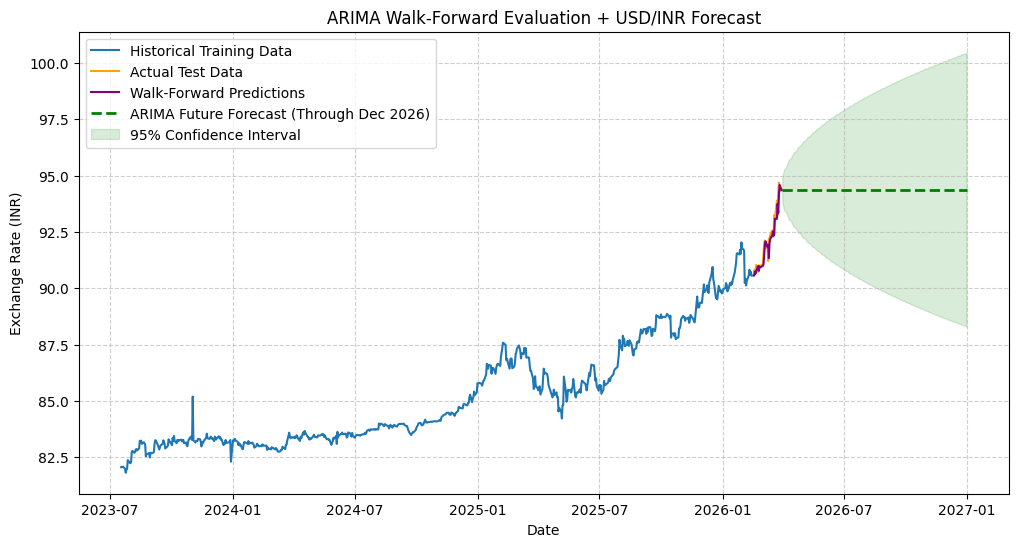

In [7]:
# Train-Test Split (Last 30 trading days for evaluation)
train_data = df['Close'][:-30]
test_data = df['Close'][-30:]

# Candidate ARIMA orders and train-only selection by AIC
candidate_orders = [(0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 0), (2, 1, 1), (2, 1, 2), (3, 1, 2)]
best_order = None
best_aic = np.inf

for order in candidate_orders:
    fitted_candidate = ARIMA(train_data, order=order).fit()
    if fitted_candidate.aic < best_aic:
        best_aic = fitted_candidate.aic
        best_order = order

print(f"Selected ARIMA order (by train AIC): {best_order}, AIC={best_aic:.2f}")

# Walk-forward one-step evaluation to avoid unstable long-horizon static prediction
history = train_data.copy()
rolling_predictions = []

for idx, actual_value in test_data.items():
    fitted_roll = ARIMA(history, order=best_order).fit()
    next_pred = float(fitted_roll.forecast(steps=1).iloc[0])
    rolling_predictions.append(next_pred)
    history = pd.concat([history, pd.Series([float(actual_value)], index=[idx])])

test_predictions = pd.Series(rolling_predictions, index=test_data.index)

# Retrain on full data for future forecasting through Dec 2026
print("Training final model on complete dataset...")
model_full = ARIMA(df['Close'], order=best_order)
fitted_full = model_full.fit()

forecast_end_date = pd.Timestamp("2026-12-31")
future_dates = pd.date_range(start=df.index[-1] + pd.offsets.BDay(1), end=forecast_end_date, freq='B')
future_steps = len(future_dates)

forecast_obj = fitted_full.get_forecast(steps=future_steps)
future_forecast = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05)

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(df.index[-700:-30], train_data.iloc[-670:], label='Historical Training Data', color='#1f77b4', linewidth=1.5)
plt.plot(test_data.index, test_data, label='Actual Test Data', color='orange', linewidth=1.5)
plt.plot(test_predictions.index, test_predictions, label='Walk-Forward Predictions', color='purple', linewidth=1.5)
plt.plot(future_dates, future_forecast, label='ARIMA Future Forecast (Through Dec 2026)', color='green', linestyle='dashed', linewidth=2)
plt.fill_between(future_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='green', alpha=0.15, label='95% Confidence Interval')
plt.title('ARIMA Walk-Forward Evaluation + USD/INR Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (INR)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


#### Model Evaluation

In [8]:
mse = mean_squared_error(test_data.values, test_predictions.values)
rmse = np.sqrt(mse)
r2 = r2_score(test_data.values, test_predictions.values)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 0.1778
Root Mean Squared Error (RMSE): 0.4217
R-squared (R²): 0.8808
